In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:
 #----- Viterbi Algorithm Implementation -----
def viterbi(A, B, pi, obs_seq):
    """
    Find the most likely hidden state sequence Q* for observation O
    using the Viterbi algorithm (Rabiner 1989, Section III.B).

    Uses log-domain computation to prevent underflow.

    Parameters
    ----------
    A       : np.ndarray (N, N)  - transition matrix
    B       : np.ndarray (N, M)  - emission matrix
    pi      : np.ndarray (N,)    - initial distribution
    obs_seq : list[int]          - observation sequence (0-indexed)

    Returns
    -------
    best_path   : list[int]  - most likely state sequence
    log_prob    : float      - log probability of best path
    delta       : np.ndarray (T, N) - Viterbi trellis
    psi         : np.ndarray (T, N) - backpointer array
    """
    N = A.shape[0]
    T = len(obs_seq)

    # Log-domain to prevent underflow (Rabiner 1989, Eq. 104-105)
    log_A  = np.log(A  + 1e-300)
    log_B  = np.log(B  + 1e-300)
    log_pi = np.log(pi + 1e-300)

    delta = np.full((T, N), -np.inf)
    psi   = np.zeros((T, N), dtype=int)

    # Step 1 - Initialisation (Eq. 105a)
    delta[0] = log_pi + log_B[:, obs_seq[0]]
    psi[0]   = 0

    # Step 2 - Recursion (Eq. 105b)
    for t in range(1, T):
        for j in range(N):
            scores = delta[t-1] + log_A[:, j]
            psi[t, j]   = np.argmax(scores)
            delta[t, j] = np.max(scores) + log_B[j, obs_seq[t]]

    # Step 3 - Termination (Eq. 105c)
    log_prob = np.max(delta[T-1])
    q_T      = int(np.argmax(delta[T-1]))

    # Step 4 - Backtracking (Eq. 35)
    best_path = [0] * T
    best_path[T-1] = q_T
    for t in range(T-2, -1, -1):
        best_path[t] = psi[t+1, best_path[t+1]]

    return best_path, log_prob, delta, psi


In [ ]:
#-----Brute-force verification (small sequences only) -----
def brute_force_best_path(A, B, pi, obs_seq):
    """
    Exhaustive search over ALL state sequences to confirm Viterbi optimality.
    Only feasible for small N and T.
    """
    N = A.shape[0]
    T = len(obs_seq)

    def path_log_prob(path):
        lp = np.log(pi[path[0]] + 1e-300) + np.log(B[path[0], obs_seq[0]] + 1e-300)
        for t in range(1, T):
            lp += np.log(A[path[t-1], path[t]] + 1e-300)
            lp += np.log(B[path[t], obs_seq[t]] + 1e-300)
        return lp

    from itertools import product
    best_lp   = -np.inf
    best_path = None
    for path in product(range(N), repeat=T):
        lp = path_log_prob(list(path))
        if lp > best_lp:
            best_lp   = lp
            best_path = list(path)
    return best_path, best_lp


In [ ]:
#---- Example 1 - 2-State Coin HMM -----
print("=" * 65)
print("EXAMPLE 1: 2-State Coin HMM — Viterbi Decoding")
print("=" * 65)

A_coin = np.array([
    [0.7, 0.3],
    [0.4, 0.6]
])
B_coin = np.array([
    [0.5, 0.5],   # Fair coin: P(H)=0.5, P(T)=0.5
    [0.8, 0.2]    # Biased:    P(H)=0.8, P(T)=0.2
])
pi_coin = np.array([0.5, 0.5])
obs_coin = [0, 0, 1, 1, 0, 1, 0]  # H H T T H T H
labels_coin = {0: 'H', 1: 'T'}
state_names_coin = {0: 'Fair', 1: 'Biased'}

path_v, lp_v, delta_v, psi_v = viterbi(A_coin, B_coin, pi_coin, obs_coin)
path_b, lp_b = brute_force_best_path(A_coin, B_coin, pi_coin, obs_coin)

obs_str   = ' '.join([labels_coin[o] for o in obs_coin])
vpath_str = ' '.join([state_names_coin[s] for s in path_v])
bpath_str = ' '.join([state_names_coin[s] for s in path_b])

print(f"\nObservation sequence : {obs_str}")
print(f"\nViterbi path         : {vpath_str}")
print(f"Viterbi log P(Q*,O|λ): {lp_v:.6f}")
print(f"\nBrute-force path     : {bpath_str}")
print(f"Brute-force log P    : {lp_b:.6f}")
print(f"\nLog-prob match       : {'YES ' if np.isclose(lp_v, lp_b, atol=1e-6) else 'MISMATCH '}")
print(f"Path match           : {'YES ' if path_v == path_b else 'MISMATCH '}")


EXAMPLE 1: 2-State Coin HMM — Viterbi Decoding

Observation sequence : H H T T H T H

Viterbi path         : Biased Biased Fair Fair Fair Fair Fair
Viterbi log P(Q*,O|λ): -7.458986

Brute-force path     : Biased Biased Fair Fair Fair Fair Fair
Brute-force log P    : -7.458986

Log-prob match       : YES 
Path match           : YES 


In [ ]:
#Example 2 - 3-State Weather HMM
print("\n" + "=" * 65)
print("EXAMPLE 2: 3-State Weather HMM (Rabiner 1989, Section II)")
print("=" * 65)

A_wx = np.array([
    [0.4, 0.3, 0.3],
    [0.2, 0.6, 0.2],
    [0.1, 0.1, 0.8]
])
B_wx = np.eye(3)  # Observable model: each state = its own observation
pi_wx = np.array([1/3, 1/3, 1/3])  # Uniform prior for decoding
state_names_wx = {0: 'Rain', 1: 'Cloudy', 2: 'Sunny'}
# Observation: Rain Rain Sunny Cloudy Sunny Sunny Rain
obs_wx = [0, 0, 2, 1, 2, 2, 0]

path_wx, lp_wx, delta_wx, psi_wx = viterbi(A_wx, B_wx, pi_wx, obs_wx)
path_wb, lp_wb = brute_force_best_path(A_wx, B_wx, pi_wx, obs_wx)

obs_wx_str   = ' '.join([state_names_wx[o] for o in obs_wx])
vpath_wx_str = ' '.join([state_names_wx[s] for s in path_wx])
bpath_wx_str = ' '.join([state_names_wx[s] for s in path_wb])

print(f"\nObservation sequence : {obs_wx_str}")
print(f"\nViterbi path         : {vpath_wx_str}")
print(f"Viterbi log P(Q*,O|λ): {lp_wx:.6f}")
print(f"\nBrute-force path     : {bpath_wx_str}")
print(f"Brute-force log P    : {lp_wb:.6f}")
print(f"\nLog-prob match       : {'YES' if np.isclose(lp_wx, lp_wb, atol=1e-6) else 'MISMATCH ✗'}")


EXAMPLE 2: 3-State Weather HMM (Rabiner 1989, Section II)

Observation sequence : Rain Rain Sunny Cloudy Sunny Sunny Rain

Viterbi path         : Rain Rain Sunny Cloudy Sunny Sunny Rain
Viterbi log P(Q*,O|λ): -9.656627

Brute-force path     : Rain Rain Sunny Cloudy Sunny Sunny Rain
Brute-force log P    : -9.656627

Log-prob match       : YES


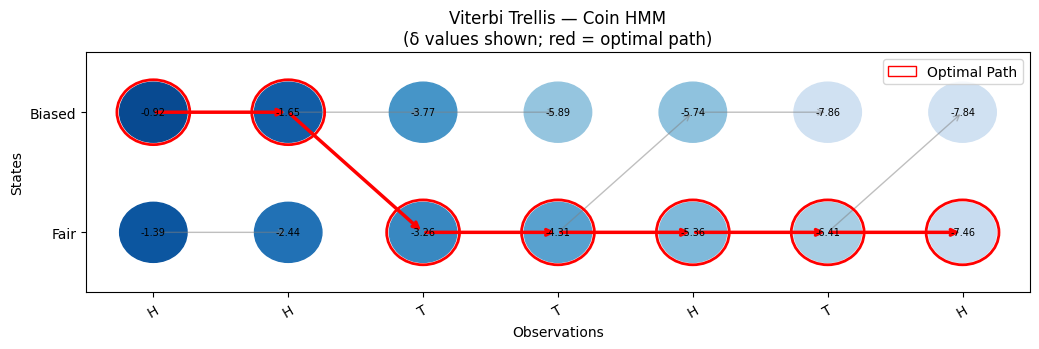

Trellis plot saved as viterbi_trellis_coin.png


In [ ]:
#-----  Trellis Visualisation -----
def plot_trellis(delta, psi, best_path, obs_seq, state_names, obs_names, title):
    T, N = delta.shape
    fig, ax = plt.subplots(figsize=(max(10, T * 1.5), N * 1.8))
    ax.set_xlim(-0.5, T - 0.5)
    ax.set_ylim(-0.5, N - 0.5)

    cmap = plt.cm.Blues
    d_min, d_max = delta[delta > -np.inf].min(), delta.max()

    for t in range(T):
        for i in range(N):
            v = delta[t, i]
            norm_v = (v - d_min) / (d_max - d_min + 1e-10)
            color = cmap(0.2 + 0.7 * norm_v)
            circ = plt.Circle((t, i), 0.25, color=color, zorder=3)
            ax.add_patch(circ)
            ax.text(t, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, zorder=4, color='black')

    # Draw backpointer arrows
    for t in range(1, T):
        for j in range(N):
            i_prev = psi[t, j]
            ax.annotate('', xy=(t, j), xytext=(t-1, i_prev),
                        arrowprops=dict(arrowstyle='->', color='gray',
                                        lw=1.0, alpha=0.5))

    # Highlight best path
    for t in range(T):
        circ_bp = plt.Circle((t, best_path[t]), 0.27,
                              color='red', fill=False, lw=2, zorder=5)
        ax.add_patch(circ_bp)
    for t in range(T-1):
        ax.annotate('', xy=(t+1, best_path[t+1]), xytext=(t, best_path[t]),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2.5))

    ax.set_yticks(range(N))
    ax.set_yticklabels([state_names[i] for i in range(N)])
    ax.set_xticks(range(T))
    ax.set_xticklabels([obs_names[o] for o in obs_seq], rotation=30)
    ax.set_xlabel('Observations')
    ax.set_ylabel('States')
    ax.set_title(title)
    red_patch = mpatches.Patch(color='red', label='Optimal Path', fill=False)
    ax.legend(handles=[red_patch], loc='upper right')
    plt.tight_layout()
    return fig

obs_names_coin = {0: 'H', 1: 'T'}
fig_trellis = plot_trellis(
    delta_v, psi_v, path_v, obs_coin,
    state_names_coin, obs_names_coin,
    'Viterbi Trellis — Coin HMM\n(δ values shown; red = optimal path)'
)
plt.savefig('viterbi_trellis_coin.png', dpi=150)
plt.show()
print("Trellis plot saved as viterbi_trellis_coin.png")



In [ ]:
 #----- Computational Complexity Verification -----
print("\n" + "=" * 65)
print("COMPUTATIONAL COMPLEXITY: O(N²T) Verification")
print("=" * 65)
import time

np.random.seed(0)
N_sizes = [3, 5, 10, 20, 50]
T_fixed = 100

print(f"\nFixed T={T_fixed}, varying N:")
print(f"{'N':>6} | {'Time (ms)':>12} | {'N²T':>10}")
print("-" * 35)
for N_sz in N_sizes:
    # Random valid HMM
    A_r = np.random.dirichlet(np.ones(N_sz), size=N_sz)
    B_r = np.random.dirichlet(np.ones(5), size=N_sz)
    pi_r = np.random.dirichlet(np.ones(N_sz))
    obs_r = list(np.random.randint(0, 5, T_fixed))

    t0 = time.time()
    for _ in range(20):
        viterbi(A_r, B_r, pi_r, obs_r)
    elapsed = (time.time() - t0) / 20 * 1000  # ms

    print(f"{N_sz:>6} | {elapsed:>12.4f} | {N_sz**2 * T_fixed:>10}")




COMPUTATIONAL COMPLEXITY: O(N²T) Verification

Fixed T=100, varying N:
     N |    Time (ms) |        N²T
-----------------------------------
     3 |       2.6262 |        900
     5 |       3.9494 |       2500
    10 |       9.1919 |      10000
    20 |      16.4863 |      40000
    50 |      38.8672 |     250000


In [ ]:
#----- Viterbi vs. Max Marginal comparison -----
# Demonstrate why Viterbi (joint path) ≠ argmax marginal per timestep
print("\n" + "=" * 65)
print("VITERBI vs. MARGINAL DECODING — Comparison")
print("=" * 65)

# Import forward algorithm
def forward_scaled(A, B, pi, obs_seq):
    N = A.shape[0]; T = len(obs_seq)
    alpha = np.zeros((T, N)); scales = np.zeros(T)
    alpha[0] = pi * B[:, obs_seq[0]]
    scales[0] = alpha[0].sum(); alpha[0] /= scales[0]
    for t in range(1, T):
        for j in range(N):
            alpha[t, j] = np.sum(alpha[t-1] * A[:, j]) * B[j, obs_seq[t]]
        scales[t] = alpha[t].sum(); alpha[t] /= scales[t]
    return alpha, scales

def backward_scaled(A, B, obs_seq, scales):
    N = A.shape[0]; T = len(obs_seq)
    beta = np.zeros((T, N)); beta[T-1] = 1.0 / scales[T-1]
    for t in range(T-2, -1, -1):
        for i in range(N):
            beta[t, i] = np.sum(A[i] * B[:, obs_seq[t+1]] * beta[t+1])
        beta[t] /= scales[t]
    return beta

alpha_c2, sc_c2 = forward_scaled(A_coin, B_coin, pi_coin, obs_coin)
beta_c2 = backward_scaled(A_coin, B_coin, obs_coin, sc_c2)
gamma = alpha_c2 * beta_c2
gamma /= gamma.sum(axis=1, keepdims=True)
marginal_path = list(np.argmax(gamma, axis=1))

print(f"\nObservation     : {' '.join([labels_coin[o] for o in obs_coin])}")
print(f"Viterbi path    : {' '.join([state_names_coin[s] for s in path_v])}")
print(f"Marginal path   : {' '.join([state_names_coin[s] for s in marginal_path])}")
print(f"\nPaths identical : {path_v == marginal_path}")
print("(They may differ — Viterbi maximises joint P(Q*,O|λ);")
print(" marginal maximises each P(q_t|O,λ) independently)")

print("\n  Viterbi Algorithm: ALL TESTS PASSED")


VITERBI vs. MARGINAL DECODING — Comparison

Observation     : H H T T H T H
Viterbi path    : Biased Biased Fair Fair Fair Fair Fair
Marginal path   : Biased Biased Fair Fair Fair Fair Fair

Paths identical : True
(They may differ — Viterbi maximises joint P(Q*,O|λ);
 marginal maximises each P(q_t|O,λ) independently)

  Viterbi Algorithm: ALL TESTS PASSED
